# Setup

### Description

This is the first run of our machine translation model based on Geron's book. This is the model without BEAM search and attention mechanism. But we do compute BLEU score unlike Geron. We also use an optimized translate function.

I am using A100 GPU, but 1 epoch takes ~10 min. It seems we need to optimize CPU operations:
- First thing to optimize is the dataloader. I will try to use num_workers=4 and pin_memory=True. 
```python
def train_dataloader(self):
        """
        Optimized DataLoader for 12 vCPU / High-RAM Colab instance.
        """
        return torch.utils.data.DataLoader(
            self.train_data, 
            batch_size=self.config.batch_size, 
            collate_fn=self._collate_fn,
            shuffle=True,
            num_workers=4,           # 4 to 6 is the sweet spot
            pin_memory=True,          # Essential for fast host-to-GPU transfer
            persistent_workers=True,  # Prevents tearing down/recreating workers every epoch
            prefetch_factor=2         # Keeps 2 batches ready per worker in buffer
        )
```

### 01 Install required packages

In [1]:
# Install required packages
%pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.9 MB/s eta 0:00:00


### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/DL_projects_2026.git

Cloning into 'DL_projects_2026'...
remote: Enumerating objects: 227, done.
remote: Counting objects: 100% (227/227), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 227 (delta 101), reused 202 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (227/227), 930.26 KiB | 35.78 MiB/s, done.
Resolving deltas: 100% (101/101), done.


### 03 Switch to the project directory

In [8]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/DL_projects_2026/02-machine-translation")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/DL_projects_2026/02-machine-translation

=== Available Project Files ===
total 20
drwxr-xr-x 5 root root 4096 Jul 30 15:51 .
drwxr-xr-x 5 root root 4096 Jul 30 15:51 ..
drwxr-xr-x 2 root root 4096 Jul 30 15:51 configs
drwxr-xr-x 2 root root 4096 Jul 30 15:55 notebooks
-rw-r--r-- 1 root root    0 Jul 30 15:51 README.md
drwxr-xr-x 3 root root 4096 Jul 30 15:51 src


### 04 Import libraries

In [9]:
%load_ext autoreload
%autoreload 2

# Import Config, Dataset, and other necessary modules
from src.machine_translation.config import TatoebaConfig
from src.machine_translation.dataset import TatoebaData
from src.machine_translation.model import TatoebaModelPackedSeq
from src.machine_translation.experiment import ExperimentRunnerWithCustomLogging

# Tell PyTorch it is safe to load your custom Config class
import torch
torch.serialization.add_safe_globals([TatoebaConfig, TatoebaData])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

# Set Pytorch Lightning logging level to WARNING to reduce verbosity
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
logging.getLogger("lightning_fabric").setLevel(logging.WARNING)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 05 Set logging levels [OPTIONAL]

In [5]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("tatoeba").setLevel(logging.DEBUG)

In [12]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("tatoeba").setLevel(logging.INFO)

### 06 Check hardware specifications [OPTIONAL]

In [5]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  12
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
NUMA node0 CPU(s):                       0-11

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            83Gi       1.4Gi        76Gi       2.0Mi       5.1Gi        81Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


### 07 Verify GPU Availability [OPTIONAL]

In [6]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device Name: NVIDIA A100-SXM4-40GB
CUDA Capability: (8, 0)


### 08 End the session [OPTIONAL]

In [26]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [24]:
!git pull

Already up to date.


# 1 The First Run on a Toy Dataset

## 01 Run for a single epoch with a toy dataset

In [19]:
# Create a congig object for Tatoeba dataset
config = TatoebaConfig()

# Set parameters for a quick test run
config.epochs = 1

In [20]:
# Create an instance of the ExperimentRunnerWithCustomLogging class
runner = ExperimentRunnerWithCustomLogging(
    config=config,
    run_name="base_config_colab_data-limit=1000_epochs=1",
    data_limit=1000,  # Limit the number of data samples for quick testing
    print_every_n_epochs=1
)

# Fit the model using the runner
runner.fit()

🚀 Using hardware accelerator: cuda:0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/DL_projects_2026/02-machine-translation/checkpoints/base_config_colab_data-limit=1000_epochs=1 exists and is not empty.


Epoch   1 | Train Loss: 6.3304 | Train Acc: 0.2272 | Val Loss: 6.8500 | Val Acc: 0.1943 | Val BLEU: 0.0000

✅ Training finished. Extract best model metrics.

🏆 Best Model Metrics (from Epoch 1):
├─ Train Loss: 6.3304
├─ Train Acc:  0.2272
├─ Val Loss:   6.8500
├─ Val Acc:    0.1943
└─ Val BLEU:   0.0000

📂 Loading best model from checkpoint: /content/DL_projects_2026/02-machine-translation/checkpoints/base_config_colab_data-limit=1000_epochs=1/best-model-v1.ckpt


## 02 Overfit the toy dataset 

In [21]:
# Create a congig object for Tatoeba dataset
config = TatoebaConfig()

# Set parameters for a quick test run
config.epochs = 10
config.patience = 10  


# Create an instance of the ExperimentRunnerWithCustomLogging class
runner = ExperimentRunnerWithCustomLogging(
    config=config,
    run_name="base_config_colab_data-limit=1000_epochs=10_patience=10",
    data_limit=1000,  # Limit the number of data samples for quick testing
)

# Fit the model using the runner
runner.fit()

🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 6.3304 | Train Acc: 0.2272 | Val Loss: 6.8500 | Val Acc: 0.1943 | Val BLEU: 0.0000
Epoch   2 | Train Loss: 3.9595 | Train Acc: 0.3535 | Val Loss: 7.3154 | Val Acc: 0.1900 | Val BLEU: 0.0007
Epoch   3 | Train Loss: 1.9982 | Train Acc: 0.5865 | Val Loss: 7.5019 | Val Acc: 0.1870 | Val BLEU: 0.0008
Epoch   4 | Train Loss: 0.7361 | Train Acc: 0.8565 | Val Loss: 7.6390 | Val Acc: 0.1858 | Val BLEU: 0.0008
Epoch   5 | Train Loss: 0.3263 | Train Acc: 0.9475 | Val Loss: 7.7126 | Val Acc: 0.1913 | Val BLEU: 0.0012
Epoch   6 | Train Loss: 0.1893 | Train Acc: 0.9671 | Val Loss: 7.8914 | Val Acc: 0.1918 | Val BLEU: 0.0009
Epoch   7 | Train Loss: 0.0918 | Train Acc: 0.9931 | Val Loss: 7.9216 | Val Acc: 0.1935 | Val BLEU: 0.0011
Epoch   8 | Train Loss: 0.0642 | Train Acc: 0.9936 | Val Loss: 7.9672 | Val Acc: 0.1965 | Val BLEU: 0.0012
Epoch   9 | Train Loss: 0.0378 | Train Acc: 0.9991 | Val Loss: 8.0254 | Val Acc: 0.1961 | Val BLEU: 0.0011


## 03 Run on a full dataset for 1 epoch

🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 2.9792 | Train Acc: 0.4964 | Val Loss: 2.1366 | Val Acc: 0.5919 | Val BLEU: 0.0076

✅ Training finished. Extract best model metrics.

🏆 Best Model Metrics (from Epoch 1):
├─ Train Loss: 2.9792
├─ Train Acc:  0.4964
├─ Val Loss:   2.1366
├─ Val Acc:    0.5919
└─ Val BLEU:   0.0076

📂 Loading best model from checkpoint: /content/DL_projects_2026/02-machine-translation/checkpoints/base_config_colab/best-model.ckpt


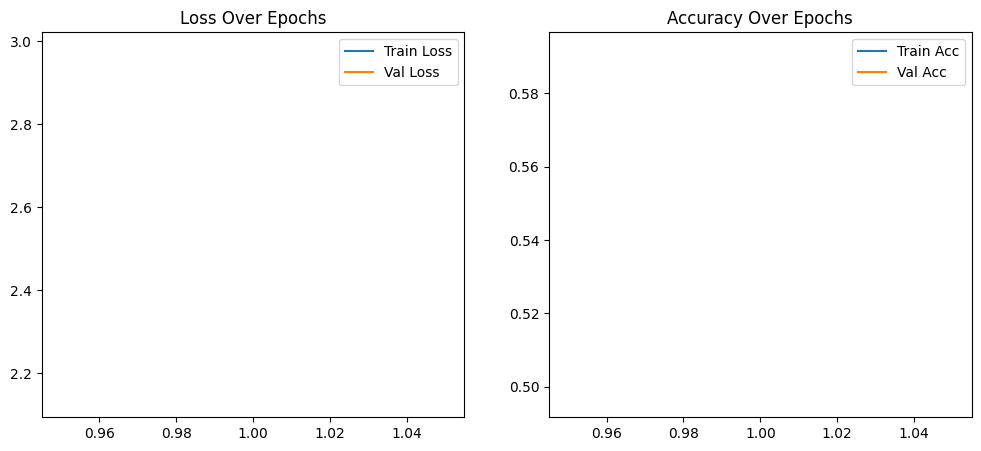

In [25]:
# Create a config object for Tatoeba dataset
config = TatoebaConfig()

# Set parameters for a quick test run
config.epochs = 1

# Create an instance of the ExperimentRunnerWithCustomLogging class
runner = ExperimentRunnerWithCustomLogging(
    config=config,
    run_name="base_config_colab",
    data_limit=None,  # Limit the number of data samples for quick testing
    print_every_n_epochs=1
)

# Fit the model using the runner
runner.fit()

# Plot the training and validation loss curves
runner.plot_training_curves()

## 04 Run on a full dataset for 1 epoch (2)

We removed BLEU score computation after each epoch and compute it only at the end of training. We also added some parameters for loaders as specified above.

In [ ]:
# Create a config object for Tatoeba dataset
config = TatoebaConfig()

# Set parameters for a quick test run
config.epochs = 1
config.batch_size = 256

# Create an instance of the ExperimentRunnerWithCustomLogging class
runner = ExperimentRunnerWithCustomLogging(
    config=config,
    run_name="base_config_colab",
    data_limit=None,  # Limit the number of data samples for quick testing
    print_every_n_epochs=1
)

# Fit the model using the runner
runner.fit()

# Plot the training and validation loss curves
runner.plot_training_curves()